<a href="https://colab.research.google.com/github/Willigon106/cogrower/blob/master/Copy_of_Actividad1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1 Preprocesamiento ágil: generación de tablas y gráficos para conocer el proyecto.
**Materia: Gestión de Proyectos de Inteligencia de Negocios**
**Maestria Universitaria en Inteligencia de Negocios**


---

Integrantes del Grupo G001:

* LUISA FERNANDA PALACIOS ROBLEDO - luisafernanda.p7066@comunidadunir.net
* MICHEL ADOLFO BLANCO LARA — micheladolfo.bl3531@comunidadunir.net
* FLOR ANGELICA ALARCÓN SUAREZ — florangelica.al0696@comunidadunir.net

**Carga** de Datos

In [6]:
# 1. Importamos las librerias pandas, numpy y matplot.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Cargamos el archivo de Excel y creamos dos DataFrames independientes ( grados y master).
excel_path = "/content/Act1_matriculas_gradoposgrado.xlsx"
df_grado = pd.read_excel(excel_path, sheet_name="Matriculados Grado")
df_master = pd.read_excel(excel_path, sheet_name="Matriculados Master")

**Proceso de Limpieza**

1. Analisis y Limpieza de los datos de los  DataFramne grados y master.

In [7]:
# 3. Realizamos la inspeccion de los datos

#  Inspeccion para DF grado
print(f"La base de datos de los Grados  {df_grado.shape[0]} filas y {df_grado.shape[1]} columnas.")
#Nombre de las columnas
print(df_grado.columns)
#Tipos de datos que tenemos
print(df_grado.dtypes)

#  Inspeccion para DF Master
print(f"La base de datos de los Masters tiene {df_master.shape[0]} filas y {df_master.shape[1]} columnas.")
#Nombre de las columnas
print(df_master.columns)
#Tipos de datos que tenemos
print(df_master.dtypes)


La base de datos de los Grados  4235 filas y 18 columnas.
Index(['Comunidad autónoma', 'Universidad', 'Rama', 'Titulación',
       'matriculas2122', 'mujeres2122', 'matriculas2021', 'mujeres2021',
       'matriculas1920', 'mujeres1920', 'matriculas1819', 'mujeres1819',
       'matriculas1718', 'mujeres1718', 'matriculas1617', 'mujeres1617',
       'matriculas1516', 'mujeres1516'],
      dtype='object')
Comunidad autónoma    object
Universidad           object
Rama                  object
Titulación            object
matriculas2122        object
mujeres2122           object
matriculas2021        object
mujeres2021           object
matriculas1920        object
mujeres1920           object
matriculas1819        object
mujeres1819           object
matriculas1718        object
mujeres1718           object
matriculas1617        object
mujeres1617           object
matriculas1516        object
mujeres1516           object
dtype: object
La base de datos de los Masters tiene 5292 filas y 18 colu

In [8]:
# 4. Revisamos la estructura de los datos con head, debido a que salen tipo object, para convertir de acuero al tipo real de dato.
print("Primeras filas de la base de datos de los Grados:")
print(df_grado.head())
print("Primeras filas de la base de datos de los Masters:")
print(df_master.head())

# Realizamos la primera conversion de datos en Grados
print("Primera conversión de los tipos de datos en Grados:")
df_grado=df_grado.convert_dtypes()
print(df_grado.dtypes)
#Primera conversion de datos en Master
print("Primera conversión de los tipos de datos en Masters:")
df_master=df_master.convert_dtypes()
print(df_master.dtypes)

#Se realiza una conversion compleja  conforme al tipo de dato observado en head.
#  Para realizar la conversion se agrupa confrome a tipo de datos Limpieza
mat_cols = [f"matriculas{c}" for c in ["2122", "2021", "1920", "1819", "1718", "1617", "1516"]]
muj_cols = [f"mujeres{c}" for c in ["2122", "2021", "1920", "1819", "1718", "1617", "1516"]]
text_cols = ["Comunidad autónoma", "Universidad", "Rama", "Titulación"]

# Esta funcion limpia  convierte las columnas a los tipos de datos  str, int64 y float, adicional se realiza la limpieza.
def preprocesar_dataset(df):
    d = df.copy()
    """Esta funcion limpia  convierte las columnas a los tipos de datos  str, int64 y float, adicional se realiza la limpieza.
     Parametros: Df -- Dataframe
      d: copia del dataframe
    """
    # Este paso limpia y convierte las columasn selecionads a texto
    for col in text_cols:
        d[col] = d[col].astype(str).str.strip()

    # En este paso en las columnas que inician con matricula se convierte a texto para quitar los puntos de miles y comas luego se  convertir primero a t a entero por que son personas.
    for col in mat_cols:
        s = d[col].astype(str).str.strip().str.replace('.', '', regex=False).str.replace(',', '', regex=False)
        d[col] = pd.to_numeric(s, errors='coerce').astype('Int64')

    # En este paso en las columnas que inician con mujeres se convierte a texto se eliminan porcentajes, se reemplaza  la coma por punto y se convierte a Float64
    for col in muj_cols:
        s = d[col].astype(str).str.strip().str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
        d[col] = pd.to_numeric(s, errors='coerce').astype('Float64')

    # Por ultimo con el metodo  convert_dtypes()  estandarizamos los tipos de datos
    return d.convert_dtypes()
# Se asignan los resultados de la funcion a las bases orginales.
df_grado = preprocesar_dataset(df_grado)
df_master = preprocesar_dataset(df_master)
print("\nTipos de datos de las bases despues de la limpieza")
print(df_grado.dtypes)

# Revision de los duplicados
dup_g = df_grado.duplicated().sum()
dup_m = df_master.duplicated().sum()
print(f"\nDuplicados: Grado = {dup_g}, Master = {dup_m}")
df_grado = df_grado.drop_duplicates()
df_df_master = df_grado.drop_duplicates()


Primeras filas de la base de datos de los Grados:
  Comunidad autónoma     Universidad                           Rama  \
0           Cataluña  Abat Oliba CEU  Ciencias Sociales y Jurídicas   
1           Cataluña  Abat Oliba CEU  Ciencias Sociales y Jurídicas   
2           Cataluña  Abat Oliba CEU  Ciencias Sociales y Jurídicas   
3           Cataluña  Abat Oliba CEU  Ciencias Sociales y Jurídicas   
4           Cataluña  Abat Oliba CEU  Ciencias Sociales y Jurídicas   

                                          Titulación matriculas2122  \
0  Graduado o Graduada en Ciencias Políticas por ...             43   
1  Graduado o Graduada en Criminología y Segurida...            146   
2  Graduado o Graduada en Derecho por la Universi...            324   
3  Graduado o Graduada en Dirección de Empresas p...            237   
4  Graduado o Graduada en Economía y Gestión por ...             84   

  mujeres2122 matriculas2021 mujeres2021 matriculas1920 mujeres1920  \
0    0.488372            

**Respuesta 1.1**

1.1 En la exploración de las bases de datos, se observó que la carga inicial identificada a las variables como tipo objecto, sin embargo luedgo de la correcion  y conversion de datos, se establecio que las  bases de datos de gardo y master, cuentan con : 4 variables tipo string(str), 7 variables tipo int (int64) y 7 variables tipo float(float64).
Despues de comprobar se han eliminado dupolicados.

**1.2 Tablas resumen (una para Grado y otra para Máster) en las que se observe, por universidad, el máximo, el mínimo, la media y la desviación típica del número de alumnos matriculados y del porcentaje de mujeres en el curso 21/22.**

In [9]:
#Para evitar errores en el calculo de la media en el porcentaje de mujeres debido, se crea una columna auxiliar 'alumnas2122'.
df_grado['alumnas2122'] = df_grado['matriculas2122'] * df_grado['mujeres2122']
df_master['alumnas2122'] = df_master['matriculas2122'] * df_master['mujeres2122']

# Derivado de la nueva columna auxiliar 'alumnas2122' se  establece el porcentaje real.
df_grado['mujeres2122_pct'] = (df_grado['mujeres2122'] * 100).round(2)
df_master['mujeres2122_pct'] = (df_master['mujeres2122'] * 100).round(2)

# la tabla resumen con las condicion establecidas
Tablaresumen_grado=df_grado.groupby('Universidad').agg({'matriculas2122':['min', 'max','mean','std'],
                                                        'mujeres2122':['min', 'max','mean','std']})
print("\nResumen grado 21/22")
print(Tablaresumen_grado)
Tablaresumen_master=df_master.groupby('Universidad').agg({'matriculas2122':['min', 'max','mean','std'],
                                                        'mujeres2122':['min', 'max','mean','std']})
print("\nResumen master 21/22")
print(Tablaresumen_master)


Resumen grado 21/22
                          matriculas2122                                \
                                     min   max        mean         std   
Universidad                                                              
A Coruña                              10  1307  250.944444  241.532717   
A Distancia de Madrid                  1   579  195.761905  173.021936   
Abat Oliba CEU                        42   418  153.333333  117.815212   
Alcalá                                 1  1085  320.509804  251.128841   
Alfonso X El Sabio                     1  1512  134.222222    282.7007   
...                                  ...   ...         ...         ...   
Valladolid                             3  1630  256.273973  317.509635   
València (Estudi General)             40  2618  583.369231  579.077865   
Vic Central de Catalunya               2  1392  282.911765  310.387672   
Vigo                                  13  1465  345.446809  308.698376   
Zaragoza         

3. Representaciones gráficas (una para Grado y otra para Máster) en las que se bserve el top 30 de universidades españolas con más alumnos sumando los 7 cursos que incluye el dataset.

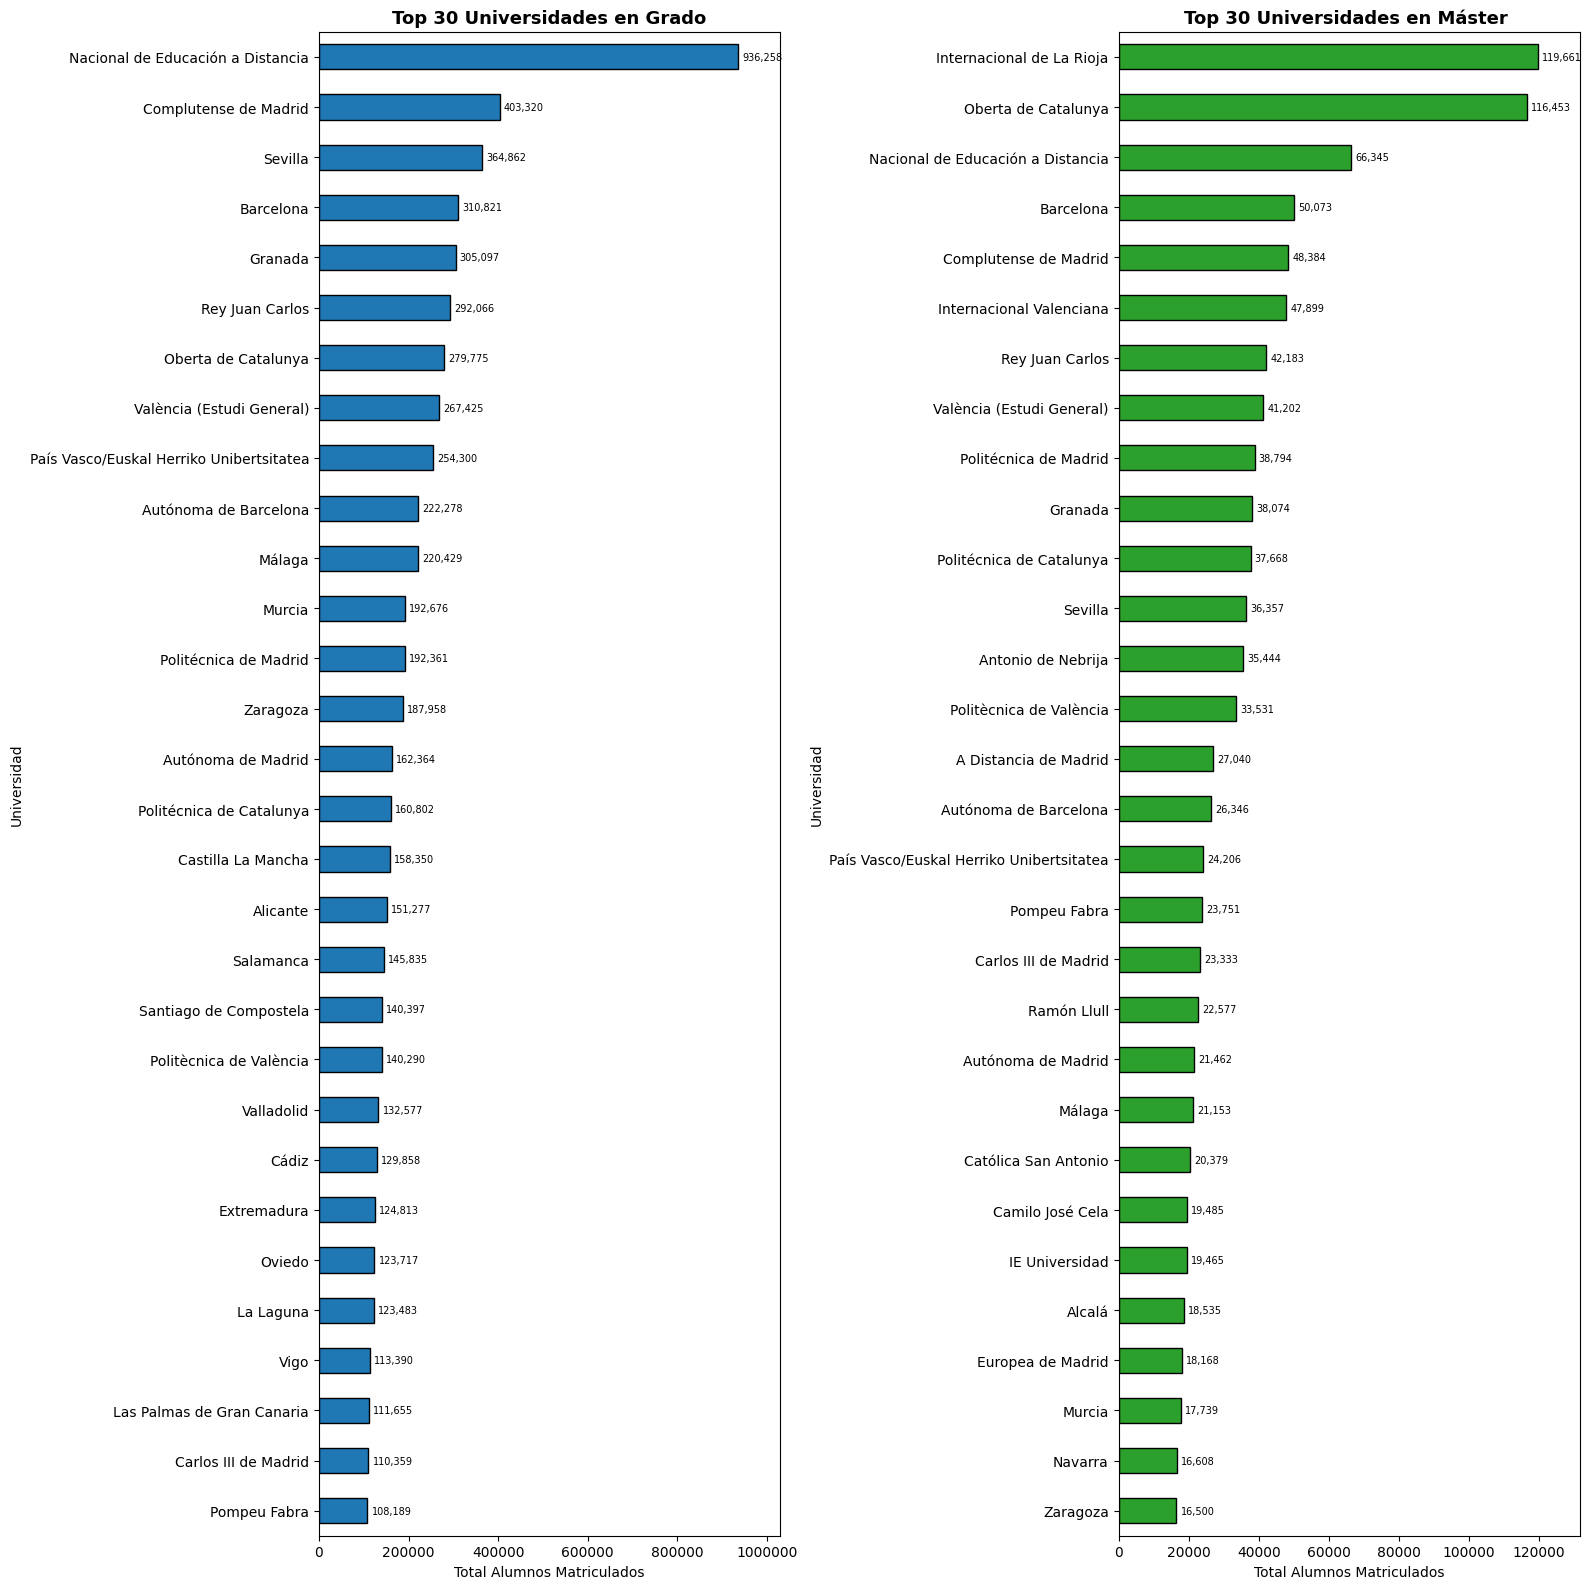


Exiten en total 19 de Universidades en los dos Top 30, las cuales son :
-Oberta de Catalunya
-Nacional de Educación a Distancia
-Barcelona
-Complutense de Madrid
-Rey Juan Carlos
-València (Estudi General)
-Politécnica de Madrid
-Granada
-Politécnica de Catalunya
-Sevilla
-Politècnica de València
-Autónoma de Barcelona
-País Vasco/Euskal Herriko Unibertsitatea
-Pompeu Fabra
-Carlos III de Madrid
-Autónoma de Madrid
-Málaga
-Murcia
-Zaragoza


In [10]:
#Antes de graficar vamos a obtener la suma de los alumnos de los 7 cursos por  universidad.
# Suma exacta horizontal a lo largo de los 7 cursos
df_grado['total_alumnos_7c'] = df_grado[mat_cols].sum(axis=1).astype('Int64')
df_master['total_alumnos_7c'] = df_master[mat_cols].sum(axis=1).astype('Int64')

# Agrupaamos por universidad, ordenamos de mayor a menor y selecionamos las 30 primeras.
top30_g = df_grado.groupby('Universidad')['total_alumnos_7c'].sum().sort_values(ascending=False).head(30)
top30_m = df_master.groupby('Universidad')['total_alumnos_7c'].sum().sort_values(ascending=False).head(30)

Valor_grado = top30_g.sort_values(ascending=True)
Valor_master = top30_m.sort_values(ascending=True)


# Graficamos con barras horizontales usando la libreria matplotlib.
fig, axes = plt.subplots(1, 2, figsize=(16, 16)) #Se establece que se van a graficas los dos graficos en el mismo layout

top30_g.sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='#1f77b4', edgecolor='black') # grafico con valores de las 30 universidades con mas alumnos por grados.
axes[0].set_title('Top 30 Universidades en Grado' , fontsize=13, fontweight='bold') #label del titulo
axes[0].set_xlabel('Total Alumnos Matriculados') # label del eje x
axes[0].set_ylabel('Universidad')  #label del eje y
axes[0].bar_label(
    axes[0].containers[0],
    labels=[f'{int(n):,}' for n in Valor_grado],
    padding=3,
    fontsize=7
)# label de las barras
axes[0].ticklabel_format(style='plain', axis='x') # Se quita la notacion cientifica para mejor visualizacion
axes[0].set_xlim(right=top30_g.max()*1.10) # Se establecen margen para evitar problemas con los labels de las barras

top30_m.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#2ca02c', edgecolor='black') # grafico con valores de las 30 universidades con mas alumnos por master.
axes[1].set_title('Top 30 Universidades en Máster ', fontsize=13, fontweight='bold') #label del titulo
axes[1].set_xlabel('Total Alumnos Matriculados') # label del eje x
axes[1].set_ylabel('Universidad')  #label del eje y
axes[1].bar_label(
    axes[1].containers[0],
    labels=[f'{int(n):,}' for n in Valor_master],
    padding=3,
    fontsize=7
)   # label de las barras

axes[1].ticklabel_format(style='plain', axis='x') # Se quita la notacion cientifica para mejor visualizacion
axes[1].set_xlim(right=top30_m.max()*1.10) # Se establecen margen para evitar problemas con los labels de las barras

plt.tight_layout()
plt.show()

# Universidades que se encuentran en el top 30 en las dos categorias.

#Se crea lista unica de los top 30 de grados
top30_g_list = top30_g.index.tolist()
#Se crea lista unica de los top 30 de master
top30_m_list= top30_m.index.tolist()

# se busca coincidencia en listas
Coincidencias= {uni: (uni in top30_g_list) for uni in top30_m_list}
Total_coincidencias = sum(Coincidencias.values())
print(f"\nExiten en total {Total_coincidencias} de Universidades en los dos Top 30, las cuales son :")
for uni, match in Coincidencias.items():
    if match:
        print(f"-{uni}")




4. La dirección general está pensando en lanzar un máster de Business Analytics vinculado a la rama “Ciencias Sociales y Jurídicas”. Por ello, piden tablas y representaciones gráficas que permitan conocer el número de alumnos y el porcentaje de mujeres en másteres de “Ciencias Sociales y Jurídicas” que contengan en su título las palabras “Inteligencia de Negocio”, “Analítica de Negocio”, “Análisis de Datos” o “Ciencia de Datos”. Ten cuidado con las mayúsculas y los espacios al hacer la búsqueda de texto.


--- 4. MÁSTERES BUSINESS ANALYTICS (EVOLUCIÓN ÚLTIMOS 3 AÑOS) ---
              Universidad                                                                                                                           Titulación  Alumnos 21/22  % Mujeres 21/22  Alumnos 20/21  % Mujeres 20/21  Alumnos 19/20  % Mujeres 19/20
Internacional de La Rioja                                         Máster Universitario en Inteligencia de Negocio por la Universidad Internacional de La Rioja            217             41.5            155             45.2             63             47.6
              Ramón Llull Máster Universitario en Análisis de Datos para los Negocios / Master of Science in Business Analytics por la Universidad Ramón Llull            133             36.1            143             28.7            116             27.6
           IE Universidad               Máster Universitario en Analítica de Negocio y Manejo de Datos / Business Analytics and Big Data por la IE Universidad          

/tmp/ipykernel_2414/773818435.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtro_texto = df_master['Titulación'].str.lower().str.contains(patron, regex=True)


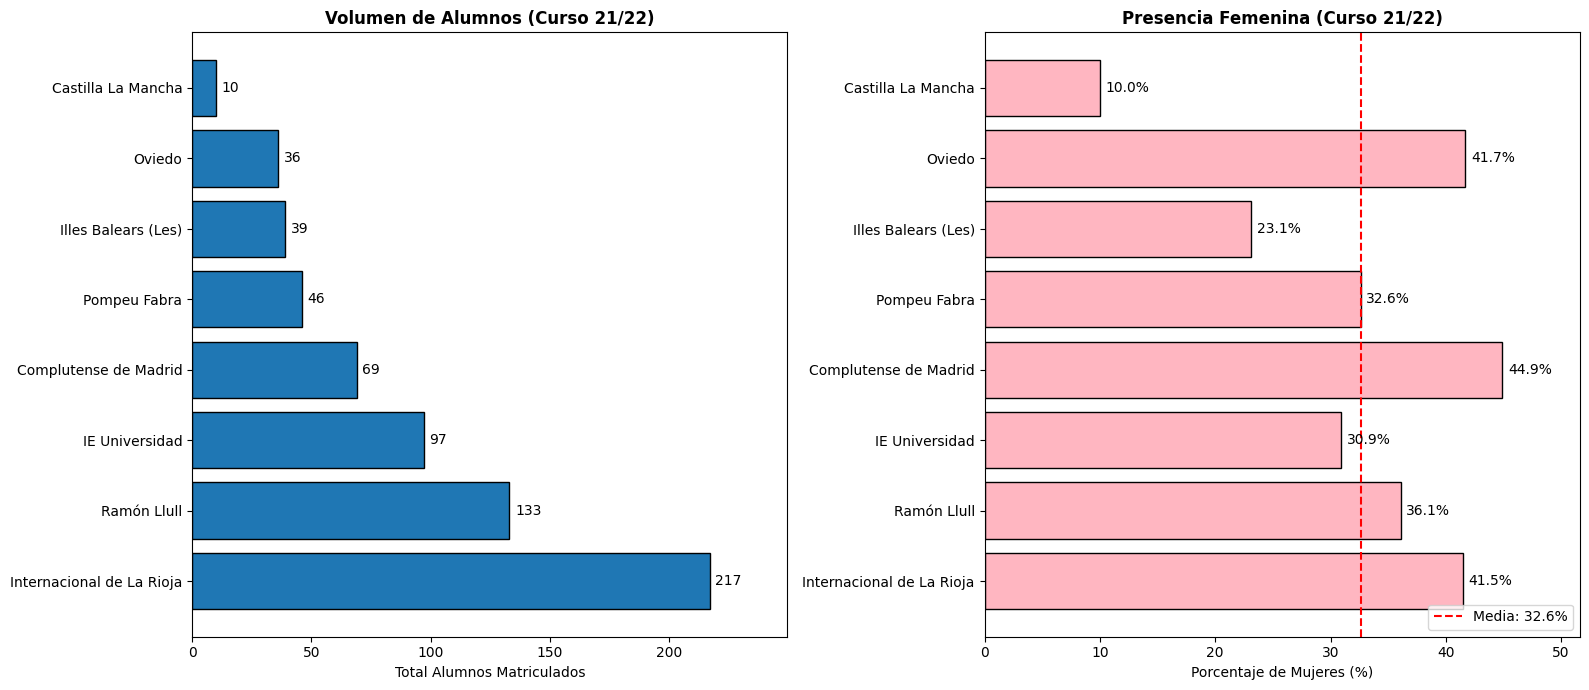

In [11]:

# Expresión regular para filtrar los títulos
patron = r'(inteligencia de negocio|anal[íi]tica de negocio|an[áa]lisis de datos|ciencia de datos)'
# Convertimos los datos, en minisculas, correjimos espacios y buscamos los datos dentro de patron
filtro_rama = df_master['Rama'].str.strip() == 'Ciencias Sociales y Jurídicas' #Filtramos por la Rama de Ciencias Sociales y Juridicas.
filtro_texto = df_master['Titulación'].str.lower().str.contains(patron, regex=True)

df_ba = df_master[filtro_rama & filtro_texto].copy()

# Convertir los porcentajes a formato 0-100 para los últimos 3 años
df_ba['pct_2122'] = (df_ba['mujeres2122'] * 100).round(1)
df_ba['pct_2021'] = (df_ba['mujeres2021'] * 100).round(1)
df_ba['pct_1920'] = (df_ba['mujeres1920'] * 100).round(1)

# Seleccionar únicamente las columnas de los últimos 3 años
columnas_recientes = [
    'Universidad',
    'Titulación',
    'matriculas2122', 'pct_2122',
    'matriculas2021', 'pct_2021',
    'matriculas1920', 'pct_1920'
]

tabla_ba_reciente = df_ba[columnas_recientes].copy()

# Asignamos unas columnas para que la tabla sea clara
tabla_ba_reciente.columns = [
    'Universidad', 'Titulación',
    'Alumnos 21/22', '% Mujeres 21/22',
    'Alumnos 20/21', '% Mujeres 20/21',
    'Alumnos 19/20', '% Mujeres 19/20'
]

# Ordenamos por el volumen de alumnos en el último año disponible (21/22)
tabla_ba_reciente = tabla_ba_reciente.sort_values(by='Alumnos 21/22', ascending=False)

print("\n--- 4. MÁSTERES BUSINESS ANALYTICS (EVOLUCIÓN ÚLTIMOS 3 AÑOS) ---")
print(tabla_ba_reciente.to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

universidades = tabla_ba_reciente['Universidad']
y_pos = np.arange(len(universidades))

# Gráfico 1, Alumnos del Curso 21/22
bars1 = axes[0].barh(y_pos, tabla_ba_reciente['Alumnos 21/22'], color='#1f77b4', edgecolor='black')
axes[0].set_title('Total de alumnos de Master las Ciencias Sociales y Juridicas relacionados a Inteligencia de Negocios en el curso 21/22', fontsize=13, fontweight='bold')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(universidades, fontsize=10)
axes[0].set_xlabel('Total Alumnos Matriculados')
axes[0].set_title('Volumen de Alumnos (Curso 21/22)', fontsize=12, fontweight='bold')
axes[0].bar_label(bars1, fmt='%.0f', padding=4)
axes[0].set_xlim(right=tabla_ba_reciente['Alumnos 21/22'].max() * 1.15) # Margen extra a la derecha

# Gráfico 2, Porcentaje de Mujeres (Curso 21/22) ---
bars2 = axes[1].barh(y_pos, tabla_ba_reciente['% Mujeres 21/22'], color='#FFB6C1', edgecolor='black')
axes[1].set_title('Porcentaje de Mujeres (Curso 21/22)', fontsize=13, fontweight='bold')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(universidades, fontsize=10)
axes[1].set_xlabel('Porcentaje de Mujeres (%)')
axes[1].set_title('Presencia Femenina (Curso 21/22)', fontsize=12, fontweight='bold')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=4)

# Añadimos una línea roja vertical para mostrar la media
media_mujeres = tabla_ba_reciente['% Mujeres 21/22'].mean()
axes[1].axvline(x=media_mujeres, color='red', linestyle='--', label=f'Media: {media_mujeres:.1f}%')
axes[1].legend(loc='lower right')
axes[1].set_xlim(right=tabla_ba_reciente['% Mujeres 21/22'].max() * 1.15)

plt.tight_layout()
plt.show()

**5.Como reflexión final, ¿son estos datos útiles para la toma de decisiones del grupo educativo? Justifica brevemente tu respuesta.**